# Cards Image Classificator

This is a PyTorch-based deep learning project focused on classifying images of playing cards. This repository explores and compares four different model architectures: a custom CNN from scratch, a CNN optimized with batch normalization and data augmentation, a feature-extraction approach using a frozen ResNet18, and a fully fine-tuned ResNet18. There are great examples of overfitting and the difference that data augmentation does to the model(slower learning but better results). Also one of the most important things in thiss dataset was to preserve RGB instead of viewing the data in Grayscale(for faster training) because the spades and hearts are very similar and without colors they would be almost undistiguishable. 

In [ ]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import pandas as pd
from PIL import Image
from google.colab import files

In [ ]:
files.upload()
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
! kaggle datasets download -d gpiosenka/cards-image-datasetclassification
! unzip cards-image-datasetclassification.zip -d cards-image-datasetclassification

In [ ]:
df = pd.read_csv("/content/cards-image-datasetclassification/cards.csv")
df.head()

,class index,filepaths,labels,card type,data set
0,0,train/ace of clubs/001.jpg,ace of clubs,ace,train
1,0,train/ace of clubs/002.jpg,ace of clubs,ace,train
2,0,train/ace of clubs/003.jpg,ace of clubs,ace,train
3,0,train/ace of clubs/004.jpg,ace of clubs,ace,train
4,0,train/ace of clubs/005.jpg,ace of clubs,ace,train


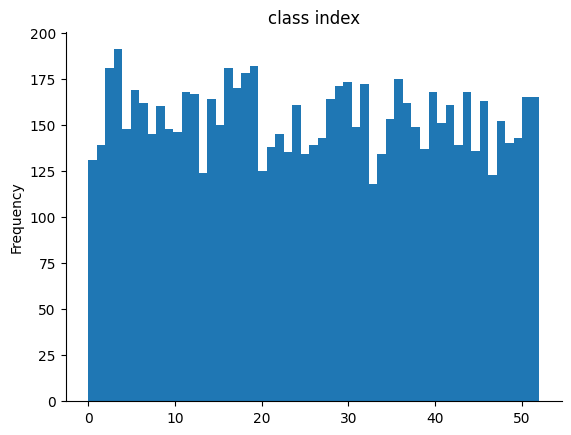

In [ ]:
# @title class index

from matplotlib import pyplot as plt
df['class index'].plot(kind='hist', bins=53, title='class index')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
df[df["data set"] == "train"].shape, df[df["data set"] == "valid"].shape, df[df["data set"] == "test"].shape,

((7625, 5), (265, 5), (265, 5))

In [ ]:
df["labels"].unique()

array(['ace of clubs', 'ace of diamonds', 'ace of hearts',
       'ace of spades', 'eight of clubs', 'eight of diamonds',
       'eight of hearts', 'eight of spades', 'five of clubs',
       'five of diamonds', 'five of hearts', 'five of spades',
       'four of clubs', 'four of diamonds', 'four of hearts',
       'four of spades', 'jack of clubs', 'jack of diamonds',
       'jack of hearts', 'jack of spades', 'joker', 'king of clubs',
       'king of diamonds', 'king of hearts', 'king of spades',
       'nine of clubs', 'nine of diamonds', 'nine of hearts',
       'nine of spades', 'queen of clubs', 'queen of diamonds',
       'queen of hearts', 'queen of spades', 'seven of clubs',
       'seven of diamonds', 'seven of hearts', 'seven of spades',
       'six of clubs', 'six of diamonds', 'six of hearts',
       'six of spades', 'ten of clubs', 'ten of diamonds',
       'ten of hearts', 'ten of spades', 'three of clubs',
       'three of diamonds', 'three of hearts', 'three of spades',

In [ ]:
train_data=df[df["data set"] == "train"]
test_data=df[df["data set"] == "test"]
val_data=df[df["data set"] == "valid"]

train_data.head()
test_data.head()
val_data.head()

,class index,filepaths,labels,card type,data set
7890,0,valid/ace of clubs/1.jpg,ace of clubs,ace,valid
7891,0,valid/ace of clubs/2.jpg,ace of clubs,ace,valid
7892,0,valid/ace of clubs/3.jpg,ace of clubs,ace,valid
7893,0,valid/ace of clubs/4.jpg,ace of clubs,ace,valid
7894,0,valid/ace of clubs/5.jpg,ace of clubs,ace,valid


In [ ]:
class PlayingCardDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        relative_path = self.dataframe.iloc[idx]['filepaths']
        img_path = os.path.join(self.root_dir, relative_path)
        image = Image.open(img_path).convert("RGB")
        label = self.dataframe.iloc[idx]['class index']
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset_root_directory = "cards-image-datasetclassification"

import os

bad_rows = []
for idx, row in df.iterrows():
    full_path = os.path.join("cards-image-datasetclassification", row['filepaths'])
    if not os.path.isfile(full_path):
        bad_rows.append((idx, full_path))

print(f"Found {len(bad_rows)} bad rows")
for idx, path in bad_rows[:10]:
    print(f"  Row {idx}: {path}")

bad_indices = [idx for idx, _ in bad_rows]
df_clean = df.drop(index=bad_indices).reset_index(drop=True)

print(f"Original rows: {len(df)}")
print(f"Clean rows:    {len(df_clean)}")

train_data = df_clean[df_clean['data set'] == 'train'].reset_index(drop=True)
val_data   = df_clean[df_clean['data set'] == 'valid'].reset_index(drop=True)
test_data  = df_clean[df_clean['data set'] == 'test'].reset_index(drop=True)

train_dataset = PlayingCardDataset(train_data, dataset_root_directory, transform=data_transforms)
valid_dataset = PlayingCardDataset(val_data, dataset_root_directory, transform=data_transforms)
test_dataset = PlayingCardDataset(test_data, dataset_root_directory, transform=data_transforms)

print(f"Training images: {len(train_dataset)}")
print(f"Validation images: {len(valid_dataset)}")
print(f"Testing images: {len(test_dataset)}")

Found 1 bad rows
  Row 120: cards-image-datasetclassification/train/ace of clubs/output
Original rows: 8155
Clean rows:    8154
Training images: 7624
Validation images: 265
Testing images: 265


In [ ]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(valid_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 239
Number of validation batches: 9
Number of testing batches: 9


In [ ]:
images, labels = next(iter(train_loader))

print("Batch Image Tensor Shape:", images.shape)
print("Batch Label Tensor Shape:", labels.shape)

Batch Image Tensor Shape: torch.Size([32, 3, 224, 224])
Batch Label Tensor Shape: torch.Size([32])


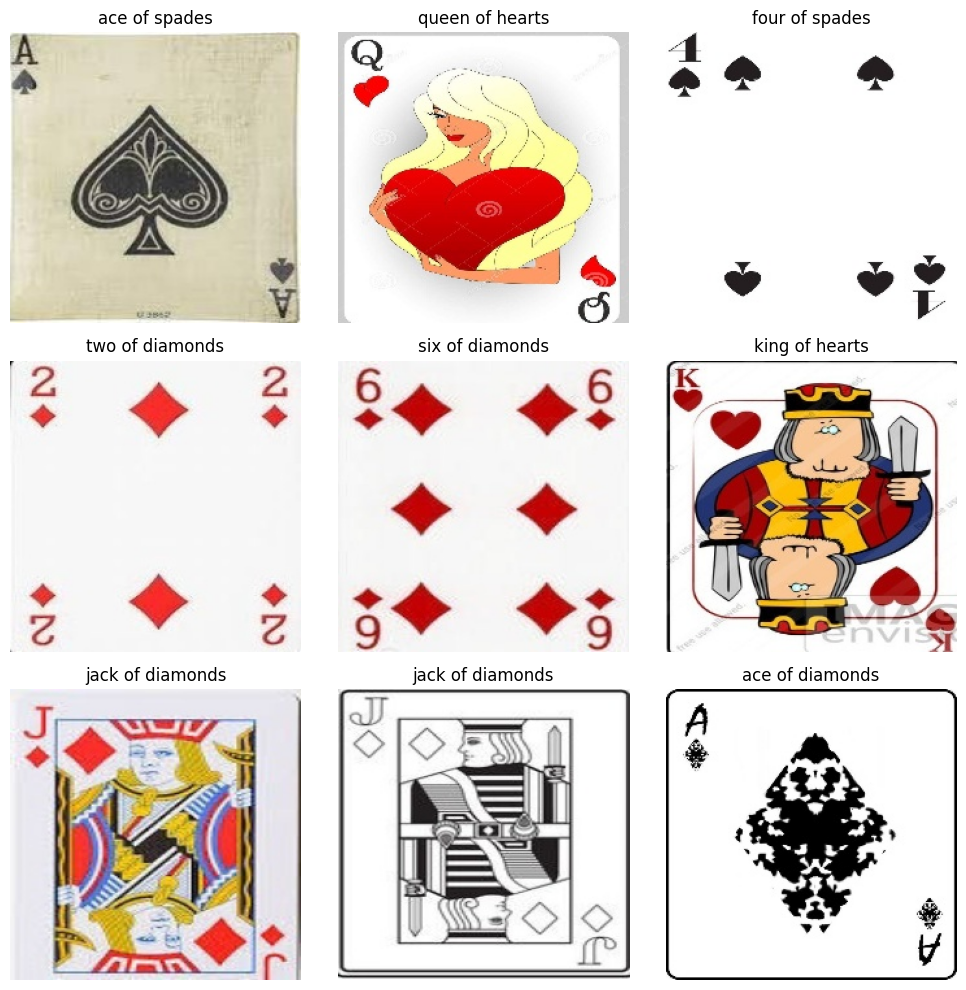

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

dataset_root_directory = "cards-image-datasetclassification"

sample = df[df['data set'] == 'train'].sample(9)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img_path = os.path.join(dataset_root_directory, row['filepaths'])
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(row['labels'])
    ax.axis('off')
plt.tight_layout()

Experiment 1: CNN from lectures made for RGB instead of Grayscale, because the color is important for distinguishing spades from hearts. We see a typical example of overfitting

  7%|▋         | 1/15 [00:24<05:46, 24.76s/it]

Epoch: 1 | train_loss: 2.6697 | train_acc: 30.7008 | test_loss: 1.4195 | test_acc: 56.7130 | time: 24.2089


 13%|█▎        | 2/15 [00:48<05:15, 24.29s/it]

Epoch: 2 | train_loss: 1.4623 | train_acc: 58.8781 | test_loss: 1.0372 | test_acc: 71.6435 | time: 23.4355


 20%|██        | 3/15 [01:11<04:44, 23.75s/it]

...

Epoch: 13 | train_loss: 0.0933 | train_acc: 98.0256 | test_loss: 1.1425 | test_acc: 77.5463 | time: 22.5605


 93%|█████████▎| 14/15 [05:24<00:23, 23.01s/it]

Epoch: 14 | train_loss: 0.0827 | train_acc: 98.1172 | test_loss: 1.1757 | test_acc: 79.1281 | time: 22.2813


100%|██████████| 15/15 [05:47<00:00, 23.16s/it]

Epoch: 15 | train_loss: 0.0949 | train_acc: 97.8033 | test_loss: 1.1892 | test_acc: 81.9059 | time: 22.0966


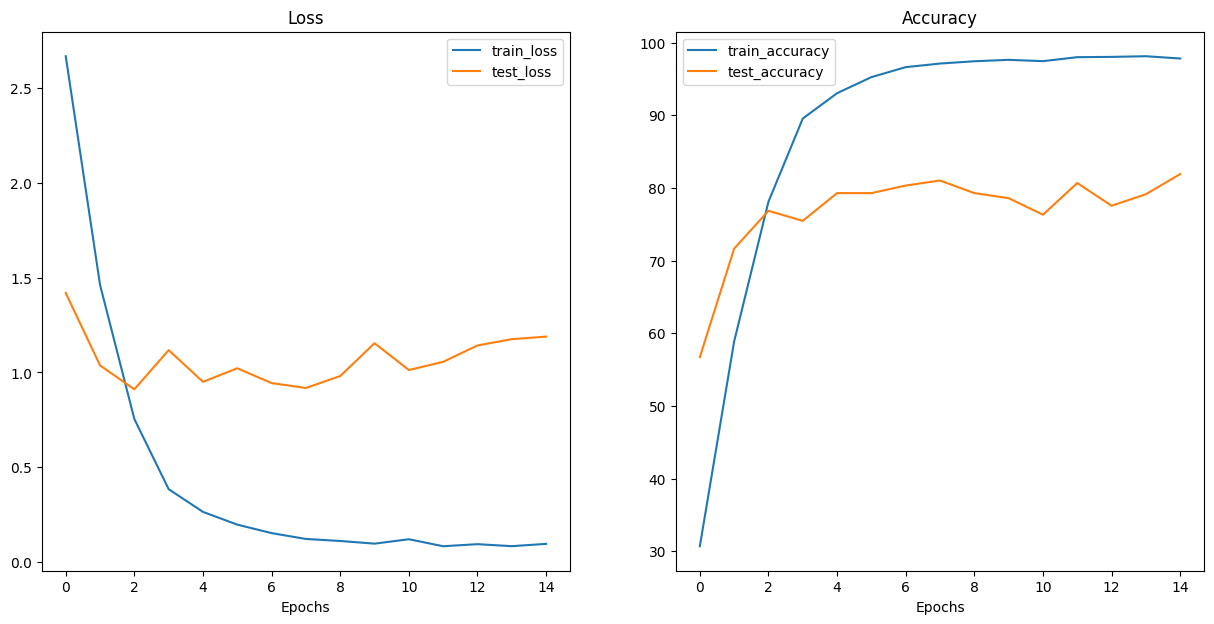

In [ ]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor
import numpy as np
from torchvision.transforms import v2
from tqdm.auto import tqdm
from timeit import default_timer as timer
from torchsummary import summary

device = "cuda" if torch.cuda.is_available() else "cpu"
device

def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc

def train_step(model, data_loader, loss_fn, optimizer, device):

    model.train()

    train_loss, train_acc = 0, 0

    for X, y in data_loader:
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    return train_loss / len(data_loader), train_acc / len(data_loader)


def test_step(model, data_loader, loss_fn, device):

    model.eval()

    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for X, y in data_loader:

            X, y = X.to(device), y.to(device)

            y_pred = model(X)

            loss = loss_fn(y_pred, y)
            test_loss += loss.item()

            test_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))

    return test_loss / len(data_loader), test_acc / len(data_loader)

def train(model,
          train_data_loader,
          test_data_loader,
          optimizer,
          loss_fn,
          epochs,
          device):

    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
        }

    model.to(device)

    for epoch in tqdm(range(epochs)):

        start_time = timer()
        train_loss, train_acc = train_step(
            model=model,
            data_loader=train_data_loader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
        )
        end_time = timer()

        test_loss, test_acc = test_step(
            model=model,
            data_loader=test_data_loader,
            loss_fn=loss_fn,
            device=device,
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f} | "
            f"time: {(end_time-start_time):.4f}"
        )

    return results

def plot_loss_curves(results):

    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()

class CNN(nn.Module):
    def __init__(self, in_channels=3, output_shape=53):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=(3,3), stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3,3), stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=(3,3), stride=1),
            nn.MaxPool2d(kernel_size=(2,2), stride=2),
            nn.ReLU()
        )
        self.linear_layers = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(in_features=128 * 27 * 27, out_features=512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=512, out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_layers(x)
        x = self.linear_layers(x)
        return x

torch.manual_seed(42)
model_0 = CNN().to(device)
next(model_0.parameters()).device

from timeit import default_timer as timer
from tqdm import tqdm

NUM_EPOCHS = 15

model_0 = CNN(in_channels=3, output_shape=53).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=1e-3)

results_0 = train(
    model=model_0,
    train_data_loader=train_loader,
    test_data_loader=valid_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
    device=device
)

plot_loss_curves(results_0)

Experiment 2: CNN from the experiment 2 but with data augmentation. I ran 40 epochs to demonstrate that it outstands the first experimenent but with more epochs it would have a limit

Output shape: torch.Size([2, 53])


  2%|▎         | 1/40 [00:24<15:44, 24.22s/it]

Epoch: 1 | train_loss: 3.5025 | train_acc: 7.9498 | test_loss: 2.8630 | test_acc: 16.0108 | time: 23.2525


  5%|▌         | 2/40 [00:48<15:17, 24.15s/it]

Epoch: 2 | train_loss: 2.9852 | train_acc: 15.2197 | test_loss: 2.6611 | test_acc: 16.6667 | time: 23.4908


...

Epoch: 38 | train_loss: 1.0950 | train_acc: 66.4880 | test_loss: 0.6236 | test_acc: 82.6003 | time: 24.0378


 98%|█████████▊| 39/40 [16:06<00:24, 24.67s/it]

Epoch: 39 | train_loss: 1.0853 | train_acc: 66.3834 | test_loss: 0.5823 | test_acc: 82.2531 | time: 24.2700


100%|██████████| 40/40 [16:31<00:00, 24.79s/it]

Epoch: 40 | train_loss: 1.0557 | train_acc: 67.7432 | test_loss: 0.5741 | test_acc: 83.2948 | time: 24.3098


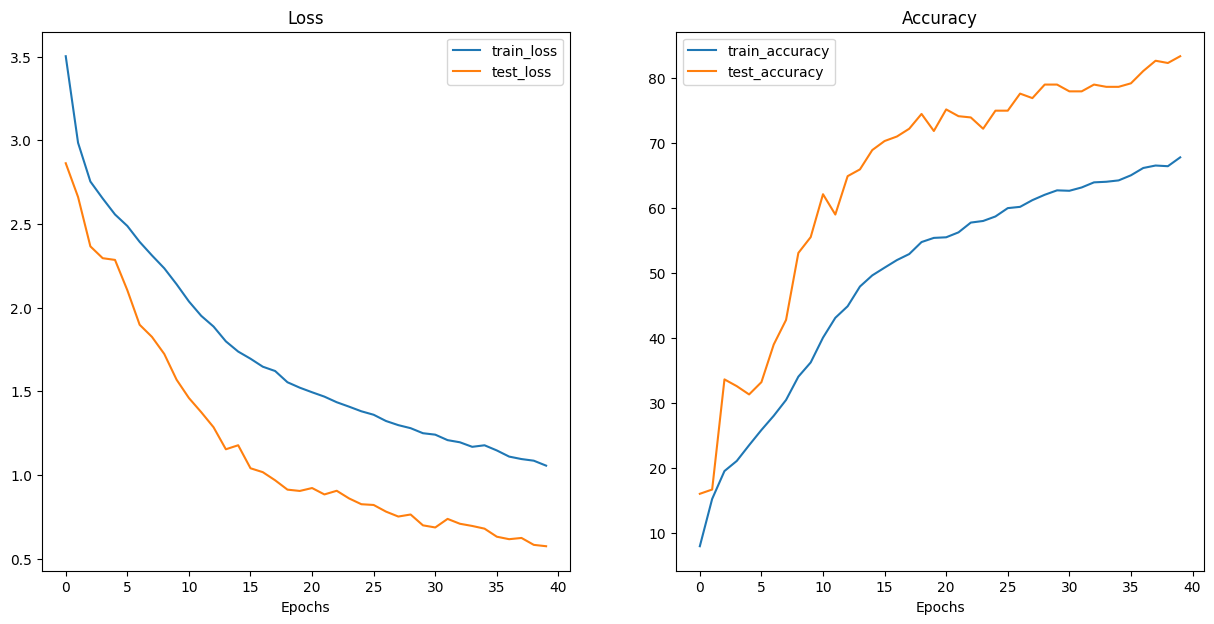

In [ ]:
train_transforms_v2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # safe
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms_v2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset_v2 = PlayingCardDataset(train_data, "cards-image-datasetclassification", transform=train_transforms_v2)
valid_dataset_v2 = PlayingCardDataset(val_data,   "cards-image-datasetclassification", transform=val_transforms_v2)
test_dataset_v2  = PlayingCardDataset(test_data,  "cards-image-datasetclassification", transform=val_transforms_v2)

train_loader_v2 = DataLoader(train_dataset_v2, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader_v2 = DataLoader(valid_dataset_v2, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader_v2  = DataLoader(test_dataset_v2,  batch_size=32, shuffle=False)

class CNN_v2(nn.Module):
    def __init__(self, in_channels=3, output_shape=53):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )
        self.linear_layers = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_layers(x)
        x = self.linear_layers(x)
        return x

dummy = torch.randn(2, 3, 224, 224).to(device)
model_2 = CNN_v2().to(device)
print(f"Output shape: {model_2(dummy).shape}")

NUM_EPOCHS = 40

loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-3)

results_2 = train(
    model=model_2,
    train_data_loader=train_loader_v2,
    test_data_loader=valid_loader_v2,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
    device=device
)

plot_loss_curves(results_2)

Experiment 3: Transfer learning ResNet with frozen backbone. It performed worst and overfits

Total params:     11,321,461
Trainable params: 144,949
Output shape: torch.Size([2, 53])


  4%|▍         | 1/25 [00:15<06:16, 15.67s/it]

Epoch: 1 | train_loss: 3.0983 | train_acc: 15.0497 | test_loss: 2.2133 | test_acc: 30.7870 | time: 15.0554


  8%|▊         | 2/25 [00:32<06:09, 16.08s/it]

Epoch: 2 | train_loss: 2.3519 | train_acc: 29.8248 | test_loss: 1.8249 | test_acc: 40.5093 | time: 15.4303


...

Epoch: 23 | train_loss: 1.1176 | train_acc: 64.2259 | test_loss: 1.3025 | test_acc: 59.7994 | time: 14.9903


 96%|█████████▌| 24/25 [06:18<00:15, 15.96s/it]

Epoch: 24 | train_loss: 1.0878 | train_acc: 65.3504 | test_loss: 1.3896 | test_acc: 59.7994 | time: 15.9890


100%|██████████| 25/25 [06:33<00:00, 15.75s/it]

Epoch: 25 | train_loss: 1.0534 | train_acc: 66.5664 | test_loss: 1.5000 | test_acc: 58.2176 | time: 15.0057


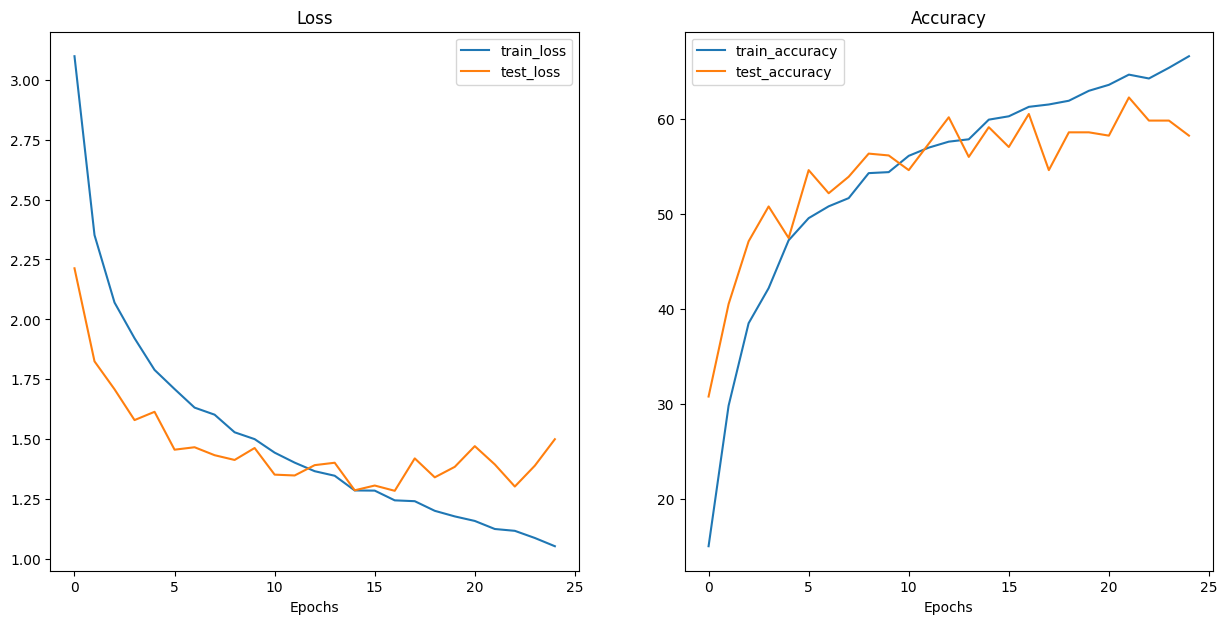

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights

train_transforms_v3 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms_v3 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset_v3 = PlayingCardDataset(train_data, "cards-image-datasetclassification", transform=train_transforms_v3)
valid_dataset_v3 = PlayingCardDataset(val_data,   "cards-image-datasetclassification", transform=val_transforms_v3)
test_dataset_v3  = PlayingCardDataset(test_data,  "cards-image-datasetclassification", transform=val_transforms_v3)

train_loader_v3 = DataLoader(train_dataset_v3, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader_v3 = DataLoader(valid_dataset_v3, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader_v3  = DataLoader(test_dataset_v3,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

model_3 = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model_3.parameters():
    param.requires_grad = False

model_3.fc = nn.Sequential(
    nn.Linear(model_3.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 53)
)

model_3 = model_3.to(device)

total_params     = sum(p.numel() for p in model_3.parameters())
trainable_params = sum(p.numel() for p in model_3.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

dummy = torch.randn(2, 3, 224, 224).to(device)
print(f"Output shape: {model_3(dummy).shape}")

NUM_EPOCHS = 25

loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_3.parameters(), lr=1e-3)

results_3 = train(
    model=model_3,
    train_data_loader=train_loader_v3,
    test_data_loader=valid_loader_v3,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
    device=device
)

plot_loss_curves(results_3)

Experiment 4: Fine-tuning ResNet with unfrozen backbone. Best results!

Total params:     11,321,461
Trainable params: 11,321,461
Output shape: torch.Size([2, 53])


  7%|▋         | 1/15 [00:30<07:10, 30.74s/it]

Epoch: 1 | train_loss: 2.5943 | train_acc: 32.7014 | test_loss: 1.0150 | test_acc: 76.8519 | time: 30.1133


 13%|█▎        | 2/15 [01:00<06:30, 30.04s/it]

Epoch: 2 | train_loss: 1.0301 | train_acc: 74.9869 | test_loss: 0.3287 | test_acc: 92.3225 | time: 28.8977


...

Epoch: 13 | train_loss: 0.0345 | train_acc: 99.3201 | test_loss: 0.0514 | test_acc: 98.2639 | time: 29.0281


 93%|█████████▎| 14/15 [06:59<00:29, 29.93s/it]

Epoch: 14 | train_loss: 0.0410 | train_acc: 99.0717 | test_loss: 0.0669 | test_acc: 98.6111 | time: 29.2249


100%|██████████| 15/15 [07:28<00:00, 29.92s/it]

Epoch: 15 | train_loss: 0.0592 | train_acc: 98.4833 | test_loss: 0.0517 | test_acc: 97.7238 | time: 29.0005


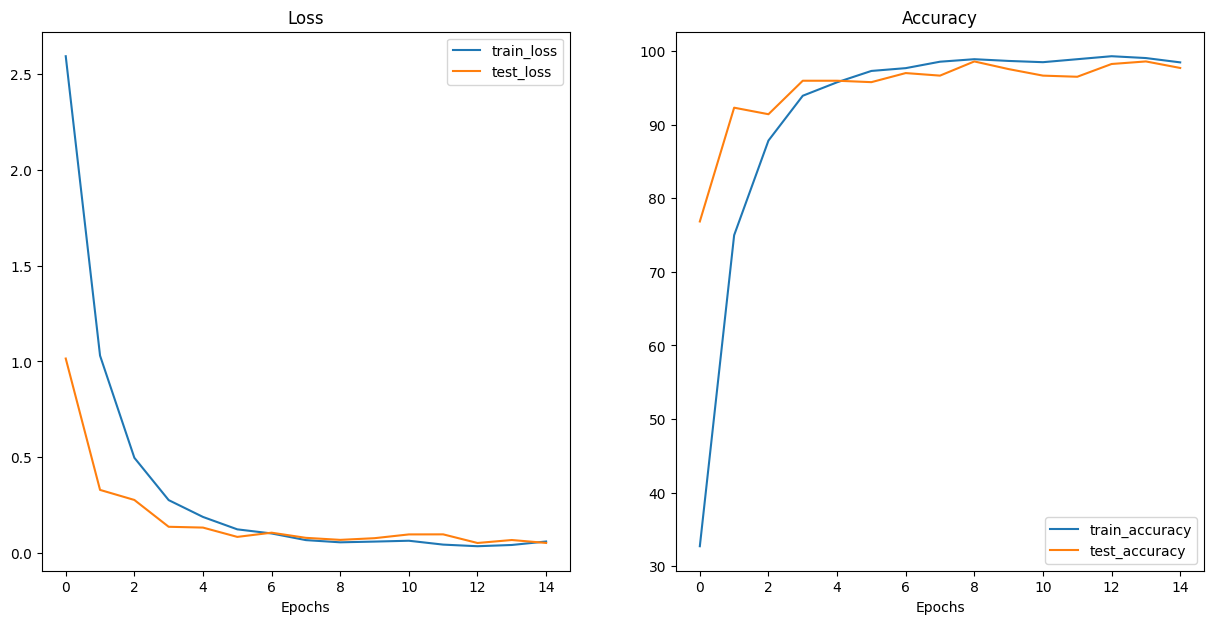

In [ ]:
train_transforms_v4 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transforms_v4 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset_v4 = PlayingCardDataset(train_data, "cards-image-datasetclassification", transform=train_transforms_v4)
valid_dataset_v4 = PlayingCardDataset(val_data,   "cards-image-datasetclassification", transform=val_transforms_v4)
test_dataset_v4  = PlayingCardDataset(test_data,  "cards-image-datasetclassification", transform=val_transforms_v4)

train_loader_v4 = DataLoader(train_dataset_v4, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
valid_loader_v4 = DataLoader(valid_dataset_v4, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader_v4  = DataLoader(test_dataset_v4,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

model_4 = resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model_4.parameters():
    param.requires_grad = True

model_4.fc = nn.Sequential(
    nn.Linear(model_4.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 53)
)

model_4 = model_4.to(device)

total_params     = sum(p.numel() for p in model_4.parameters())
trainable_params = sum(p.numel() for p in model_4.parameters() if p.requires_grad)
print(f"Total params:     {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

dummy = torch.randn(2, 3, 224, 224).to(device)
print(f"Output shape: {model_4(dummy).shape}")

NUM_EPOCHS = 15

loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_4.parameters(), lr=1e-4)

results_4 = train(
    model=model_4,
    train_data_loader=train_loader_v4,
    test_data_loader=valid_loader_v4,
    optimizer=optimizer,
    loss_fn=loss_fn,
    epochs=NUM_EPOCHS,
    device=device
)

plot_loss_curves(results_4)

Results from the best model- number 4:

In [ ]:
test_loss, test_acc = test_step(model_4, test_loader_v4, loss_fn, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Test Loss: 0.0605 | Test Acc: 98.26%


Visualized results from all experiments:

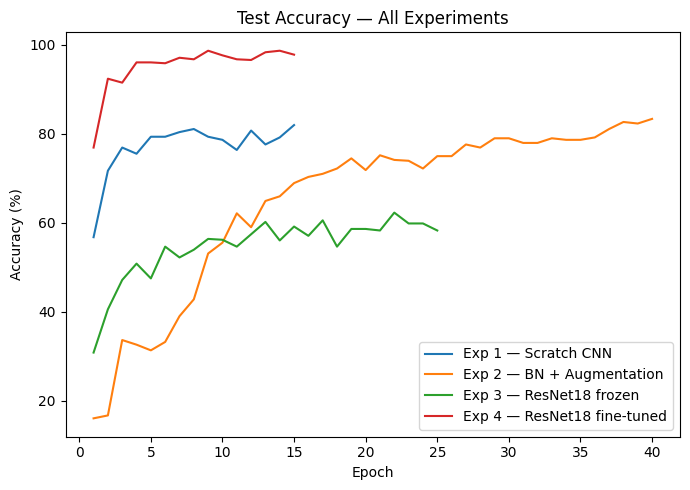

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(results_0["test_acc"]) + 1), results_0["test_acc"], label="Exp 1 — Scratch CNN")
plt.plot(range(1, len(results_2["test_acc"]) + 1), results_2["test_acc"], label="Exp 2 — BN + Augmentation")
plt.plot(range(1, len(results_3["test_acc"]) + 1), results_3["test_acc"], label="Exp 3 — ResNet18 frozen")
plt.plot(range(1, len(results_4["test_acc"]) + 1), results_4["test_acc"], label="Exp 4 — ResNet18 fine-tuned")
plt.title("Test Accuracy — All Experiments")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()

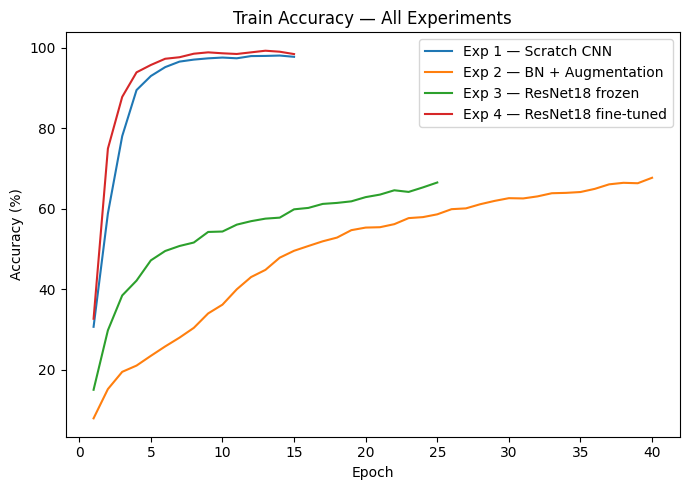

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(results_0["train_acc"]) + 1), results_0["train_acc"], label="Exp 1 — Scratch CNN")
plt.plot(range(1, len(results_2["train_acc"]) + 1), results_2["train_acc"], label="Exp 2 — BN + Augmentation")
plt.plot(range(1, len(results_3["train_acc"]) + 1), results_3["train_acc"], label="Exp 3 — ResNet18 frozen")
plt.plot(range(1, len(results_4["train_acc"]) + 1), results_4["train_acc"], label="Exp 4 — ResNet18 fine-tuned")
plt.title("Train Accuracy — All Experiments")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.tight_layout()
plt.show()